### Datarisk Case - Data Science

Este notebook é o principal entregável do case e concentra todo o desenvolvimento da solução, do início ao fim. As etapas planejadas são:

**Etapa 1 - Análise Exploratória de Dados (EDA)**
Investigação individual de cada uma das quatro bases (cadastral, info, pagamentos_desenvolvimento e pagamentos_teste): estrutura, tipos, nulos, duplicatas, inconsistências lógicas e distribuições relevantes. Inclui também a construção e validação da variável target (inadimplência = atraso ≥ 5 dias), feita a partir da base de desenvolvimento.

**Etapa 2 - Merges e Feature Engineering**
União das quatro bases via `ID_CLIENTE` e `SAFRA_REF`, construindo a base consolidada de modelagem. Nesta etapa também são criadas novas variáveis, tratados componentes existentes (datas, categóricas, valores faltantes) e definidas estratégias para casos especiais (clientes sem histórico, inconsistências identificadas na EDA).

**Etapa 3 - Modelagem**
Treinamento e validação de modelo(s) de machine learning para estimar a probabilidade de inadimplência, com avaliação de métricas apropriadas ao problema.

**Etapa 4 - Interpretação dos Resultados**
Avaliação da performance do modelo, análise das variáveis mais relevantes e validação das previsões sob a ótica de negócio, seguida da geração do arquivo final `submissao_case.csv`.

Mais detalhes acerca do contexto do projeto, decisões tomadas e conclusões podem ser encontradas no notebook "relatorio_solucao.ipynb".

In [92]:
# Importando bibliotecas necessárias
import pandas as pd
import matplotlib.pyplot as plt


In [93]:
# Carregando as 4 bases fornecidas para o case e ajustando o separador para ';'
cadastral = pd.read_csv('../data/base_cadastral.csv', sep=';')
info = pd.read_csv('../data/base_info.csv', sep=';')
pagamentos_dev = pd.read_csv('../data/base_pagamentos_desenvolvimento.csv', sep=';')
pagamentos_teste = pd.read_csv('../data/base_pagamentos_teste.csv', sep=';')


### EDA

#### Base Cadastral

In [94]:
# Visão geral da estrutura
cadastral.head()

,ID_CLIENTE,DATA_CADASTRO,DDD,FLAG_PF,SEGMENTO_INDUSTRIAL,DOMINIO_EMAIL,PORTE,CEP_2_DIG
0,1661240395903230676,2013-08-22,99,NaN,Serviços,YAHOO,PEQUENO,65
1,8274986328479596038,2017-01-25,31,NaN,Comércio,YAHOO,MEDIO,77
2,345447888460137901,2000-08-15,75,NaN,Serviços,HOTMAIL,PEQUENO,48
3,1003144834589372198,2017-08-06,49,NaN,Serviços,OUTLOOK,PEQUENO,89
4,324916756972236008,2011-02-14,88,NaN,Serviços,GMAIL,GRANDE,62


In [95]:
cadastral.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1315 entries, 0 to 1314
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   ID_CLIENTE           1315 non-null   int64 
 1   DATA_CADASTRO        1315 non-null   object
 2   DDD                  1078 non-null   object
 3   FLAG_PF              66 non-null     object
 4   SEGMENTO_INDUSTRIAL  1232 non-null   object
 5   DOMINIO_EMAIL        1285 non-null   object
 6   PORTE                1274 non-null   object
 7   CEP_2_DIG            1315 non-null   object
dtypes: int64(1), object(7)
memory usage: 82.3+ KB


In [96]:
cadastral['FLAG_PF'].value_counts()

FLAG_PF
X    66
Name: count, dtype: int64

In [97]:
# Convertendo DATA_CADASTRO para datetime
cadastral['DATA_CADASTRO'] = pd.to_datetime(cadastral['DATA_CADASTRO'])

# Criando flag binária para pessoa física (1 = PF, 0 = PJ)
# Original: 'X' para PF e NaN para PJ
cadastral['FLAG_PF'] = cadastral['FLAG_PF'].map({'X': 1})
cadastral['FLAG_PF'] = cadastral['FLAG_PF'].fillna(0).astype(int)

In [98]:
# Testando hipótese: nulos em SEGMENTO_INDUSTRIAL e PORTE coincidem com clientes PF?
# Separando os clientes em dois grupos: PF e PJ
clientes_pf = cadastral[cadastral['FLAG_PF'] == 1]
clientes_pj = cadastral[cadastral['FLAG_PF'] == 0]

# Calculando percentual de nulos em SEGMENTO_INDUSTRIAL para cada grupo
pct_nulo_segmento_pf = clientes_pf['SEGMENTO_INDUSTRIAL'].isna().sum() / len(clientes_pf)
pct_nulo_segmento_pj = clientes_pj['SEGMENTO_INDUSTRIAL'].isna().sum() / len(clientes_pj)

# Calculando percentual de nulos em PORTE para cada grupo
pct_nulo_porte_pf = clientes_pf['PORTE'].isna().sum() / len(clientes_pf)
pct_nulo_porte_pj = clientes_pj['PORTE'].isna().sum() / len(clientes_pj)

print(f'SEGMENTO_INDUSTRIAL nulo - PF: {pct_nulo_segmento_pf:.2%}')
print(f'SEGMENTO_INDUSTRIAL nulo - PJ: {pct_nulo_segmento_pj:.2%}')
print(f'PORTE nulo - PF: {pct_nulo_porte_pf:.2%}')
print(f'PORTE nulo - PJ: {pct_nulo_porte_pj:.2%}')

SEGMENTO_INDUSTRIAL nulo - PF: 100.00%
SEGMENTO_INDUSTRIAL nulo - PJ: 1.36%
PORTE nulo - PF: 3.03%
PORTE nulo - PJ: 3.12%


In [99]:
# SEGMENTO_INDUSTRIAL: nulo é estrutural para PF. Tratamos como categoria própria "PESSOA_FISICA".
# Para os poucos nulos remanescentes em PJ, tratamos como "Desconhecido".
cadastral.loc[(cadastral['SEGMENTO_INDUSTRIAL'].isna()) & (cadastral['FLAG_PF'] == 1), 'SEGMENTO_INDUSTRIAL'] = 'PESSOA_FISICA'
cadastral['SEGMENTO_INDUSTRIAL'] = cadastral['SEGMENTO_INDUSTRIAL'].fillna('Desconhecido')

# PORTE: nulos não têm relação com FLAG_PF (distribuição parecida nos dois grupos),
# então tratamos todos como "Desconhecido"
cadastral['PORTE'] = cadastral['PORTE'].fillna('Desconhecido')

# DDD e DOMINIO_EMAIL: nulos tratamos como "Desconhecido"
cadastral['DDD'] = cadastral['DDD'].fillna('Desconhecido')
cadastral['DOMINIO_EMAIL'] = cadastral['DOMINIO_EMAIL'].fillna('Desconhecido')

In [100]:
#Confirmando tratamento de nulos
print('Nulos após tratamento:')
print(cadastral.isna().sum())

Nulos após tratamento:
ID_CLIENTE             0
DATA_CADASTRO          0
DDD                    0
FLAG_PF                0
SEGMENTO_INDUSTRIAL    0
DOMINIO_EMAIL          0
PORTE                  0
CEP_2_DIG              0
dtype: int64


In [101]:
# Verificando duplicatas de linha inteira
print('Linhas duplicadas (todas as colunas):', cadastral.duplicated().sum())

# Verificando duplicatas de ID_CLIENTE (deveria ser único por cliente)
print('IDs duplicados:', cadastral['ID_CLIENTE'].duplicated().sum())


Linhas duplicadas (todas as colunas): 0
IDs duplicados: 0


#### Base Info

In [102]:
# Visão geral da estrutura
info.head()

,ID_CLIENTE,SAFRA_REF,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
0,1661240395903230676,2018-09,16913.0,NaN
1,8274986328479596038,2018-09,106430.0,141.0
2,345447888460137901,2018-09,707439.0,99.0
3,1003144834589372198,2018-09,239659.0,96.0
4,324916756972236008,2018-09,203123.0,103.0


In [103]:
info.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24401 entries, 0 to 24400
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_CLIENTE          24401 non-null  int64  
 1   SAFRA_REF           24401 non-null  object 
 2   RENDA_MES_ANTERIOR  23684 non-null  float64
 3   NO_FUNCIONARIOS     23149 non-null  float64
dtypes: float64(2), int64(1), object(1)
memory usage: 762.7+ KB


In [104]:
# Convertendo SAFRA_REF para datetime (formato YYYY-MM)
info['SAFRA_REF'] = pd.to_datetime(info['SAFRA_REF'], format='%Y-%m')

# Checando duplicatas: a combinação ID_CLIENTE + SAFRA_REF deveria ser única
print('Duplicatas (ID_CLIENTE + SAFRA_REF):', info.duplicated(subset=['ID_CLIENTE', 'SAFRA_REF']).sum())

# Estatísticas descritivas das colunas numéricas
info[['RENDA_MES_ANTERIOR', 'NO_FUNCIONARIOS']].describe()

Duplicatas (ID_CLIENTE + SAFRA_REF): 0


,RENDA_MES_ANTERIOR,NO_FUNCIONARIOS
count,2.368400e+04,23149.000000
mean,2.887514e+05,117.799646
std,2.115948e+05,21.464574
min,1.050000e+02,0.000000
25%,1.338662e+05,106.000000
50%,2.409985e+05,118.000000
75%,3.925018e+05,131.000000
max,1.682759e+06,198.000000


In [105]:
# Quantos registros têm RENDA_MES_ANTERIOR muito baixa (ex: abaixo de 1000)?
print(info[info['RENDA_MES_ANTERIOR'] < 1000].shape[0])

# Quantos registros têm NO_FUNCIONARIOS igual a 0?
print(info[info['NO_FUNCIONARIOS'] == 0].shape[0])

15
214


In [106]:
# Analisando a distribuição de nulos nas colunas RENDA_MES_ANTERIOR e NO_FUNCIONARIOS
# Verificando se os nulos se concentram em poucos clientes específicos
clientes_com_nulo_renda = info[info['RENDA_MES_ANTERIOR'].isna()]['ID_CLIENTE'].nunique()
clientes_com_nulo_func = info[info['NO_FUNCIONARIOS'].isna()]['ID_CLIENTE'].nunique()

print('Clientes distintos com renda nula:', clientes_com_nulo_renda)
print('Clientes distintos com funcionários nulo:', clientes_com_nulo_func)

# Verificando se os nulos se concentram em alguma SAFRA_REF específica
print(info[info['RENDA_MES_ANTERIOR'].isna()]['SAFRA_REF'].value_counts().head())
print(info[info['NO_FUNCIONARIOS'].isna()]['SAFRA_REF'].value_counts().head())

Clientes distintos com renda nula: 475
Clientes distintos com funcionários nulo: 681
SAFRA_REF
2019-10-01    27
2021-09-01    26
2020-07-01    24
2021-05-01    24
2020-11-01    23
Name: count, dtype: int64
SAFRA_REF
2021-09-01    46
2021-11-01    43
2021-03-01    42
2019-07-01    40
2021-08-01    39
Name: count, dtype: int64


#### Base Pagamentos desenvolvimento

In [107]:
# Visão geral da estrutura
pagamentos_dev.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_PAGAMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,1661240395903230676,2018-08,2018-08-17,2018-09-06,2018-09-06,35516.41,6.99
1,1661240395903230676,2018-08,2018-08-19,2018-09-11,2018-09-10,17758.21,6.99
2,1661240395903230676,2018-08,2018-08-26,2018-09-18,2018-09-17,17431.96,6.99
3,1661240395903230676,2018-08,2018-08-30,2018-10-11,2018-10-05,1341.00,6.99
4,1661240395903230676,2018-08,2018-08-31,2018-09-20,2018-09-20,21309.85,6.99


In [108]:
pagamentos_dev.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 77414 entries, 0 to 77413
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              77414 non-null  int64  
 1   SAFRA_REF               77414 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  77414 non-null  object 
 3   DATA_PAGAMENTO          77414 non-null  object 
 4   DATA_VENCIMENTO         77414 non-null  object 
 5   VALOR_A_PAGAR           76244 non-null  float64
 6   TAXA                    77414 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 4.1+ MB


In [109]:
# Convertendo as colunas de data para datetime
pagamentos_dev['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(pagamentos_dev['DATA_EMISSAO_DOCUMENTO'])
pagamentos_dev['DATA_VENCIMENTO'] = pd.to_datetime(pagamentos_dev['DATA_VENCIMENTO'])
pagamentos_dev['DATA_PAGAMENTO'] = pd.to_datetime(pagamentos_dev['DATA_PAGAMENTO'])

# SAFRA_REF também precisa virar datetime (formato YYYY-MM, igual na base_info)
pagamentos_dev['SAFRA_REF'] = pd.to_datetime(pagamentos_dev['SAFRA_REF'], format='%Y-%m')

# Calculando os dias de atraso: diferença entre pagamento e vencimento
pagamentos_dev['DIAS_ATRASO'] = (pagamentos_dev['DATA_PAGAMENTO'] - pagamentos_dev['DATA_VENCIMENTO']).dt.days

# Construindo a target: inadimplente se atraso for de 5 dias ou mais
pagamentos_dev['TARGET_INADIMPLENCIA'] = (pagamentos_dev['DIAS_ATRASO'] >= 5).astype(int)

# Checando a distribuição da target (proporção de inadimplentes)
print(pagamentos_dev['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

TARGET_INADIMPLENCIA
0    0.92978
1    0.07022
Name: proportion, dtype: float64


In [110]:
# Estatísticas descritivas dos dias de atraso
print(pagamentos_dev['DIAS_ATRASO'].describe())
print()

# Distribuição de atraso apenas entre os inadimplentes (atraso >= 5 dias)
print(pagamentos_dev[pagamentos_dev['TARGET_INADIMPLENCIA'] == 1]['DIAS_ATRASO'].describe())

count    77414.000000
mean        -0.171429
std         25.229477
min      -2661.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        869.000000
Name: DIAS_ATRASO, dtype: float64

count    5436.000000
mean       19.813466
std        36.716926
min         5.000000
25%         6.000000
50%         8.000000
75%        17.000000
max       869.000000
Name: DIAS_ATRASO, dtype: float64


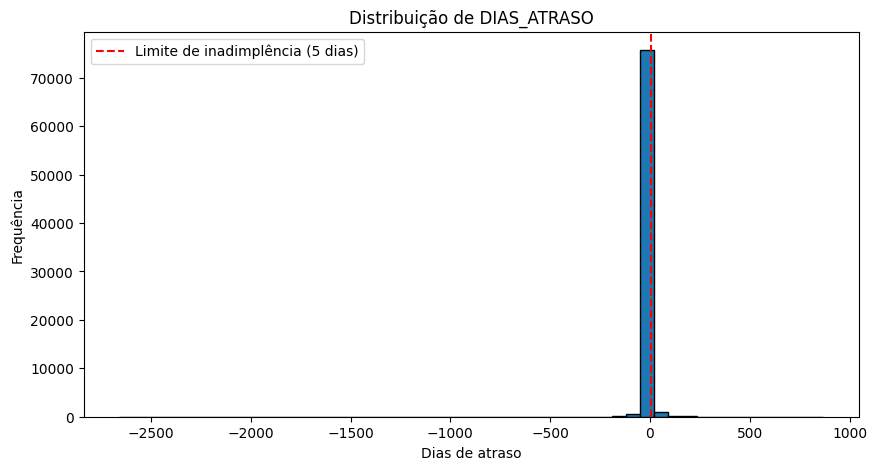

In [111]:
# Histograma da distribuição de DIAS_ATRASO (todos os registros)
plt.figure(figsize=(10, 5))
plt.hist(pagamentos_dev['DIAS_ATRASO'], bins=50, edgecolor='black')
plt.axvline(x=5, color='red', linestyle='--', label='Limite de inadimplência (5 dias)')
plt.xlabel('Dias de atraso')
plt.ylabel('Frequência')
plt.title('Distribuição de DIAS_ATRASO')
plt.legend()
plt.show()

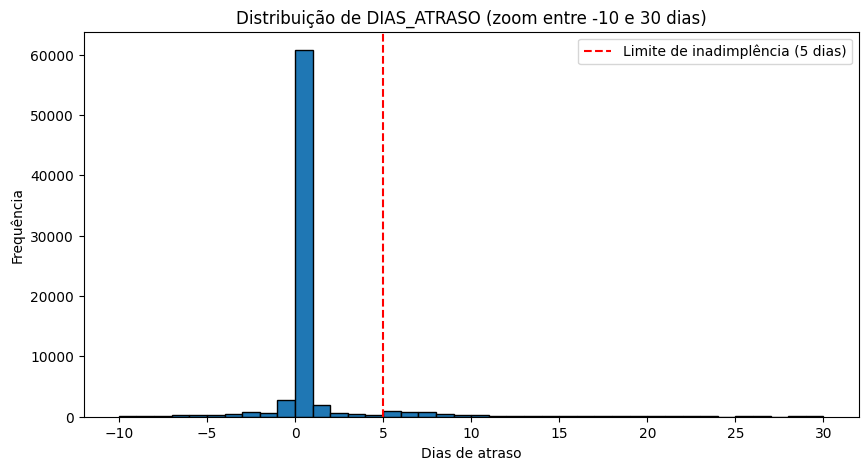

In [112]:
# Histograma focado na região entre -10 e 30 dias, para ver melhor o comportamento perto do corte
plt.figure(figsize=(10, 5))
plt.hist(pagamentos_dev['DIAS_ATRASO'], bins=40, range=(-10, 30), edgecolor='black')
plt.axvline(x=5, color='red', linestyle='--', label='Limite de inadimplência (5 dias)')
plt.xlabel('Dias de atraso')
plt.ylabel('Frequência')
plt.title('Distribuição de DIAS_ATRASO (zoom entre -10 e 30 dias)')
plt.legend()
plt.show()

In [113]:
# Investigando os outliers extremos de DIAS_ATRASO
outliers_negativos = pagamentos_dev[pagamentos_dev['DIAS_ATRASO'] < -365]
outliers_positivos = pagamentos_dev[pagamentos_dev['DIAS_ATRASO'] > 365]

print('Registros com atraso menor que -365 dias:', len(outliers_negativos))
print('Registros com atraso maior que 365 dias:', len(outliers_positivos))

# Olhando as linhas específicas para entender o padrão
print(outliers_negativos[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO']].head(10))
print(outliers_positivos[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO']].head(10))

Registros com atraso menor que -365 dias: 18
Registros com atraso maior que 365 dias: 7
                ID_CLIENTE DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  \
2362   2451708306555441014             2018-09-20      2020-08-02   
3751   4593070249039532001             2018-10-03      2021-10-31   
5166   8724731934863284019             2018-11-04      2024-01-28   
5167   8724731934863284019             2018-11-04      2024-01-28   
15995  1366416810235233769             2019-03-27      2022-02-28   
27453  4820852183212661131             2019-08-29      2022-01-31   
27454  4820852183212661131             2019-08-29      2022-01-31   
33271  3829967475074118757             2019-12-01      2027-03-31   
34543  1097345589386012260             2019-11-20      2025-08-27   
36899  1118514612547157551             2019-12-29      2023-08-03   

      DATA_PAGAMENTO  DIAS_ATRASO  
2362      2018-10-08         -664  
3751      2018-10-22        -1105  
5166      2018-11-19        -1896  
5167    

In [114]:
# Verificando inconsistência lógica: vencimento não pode ser anterior à emissão
inconsistentes = pagamentos_dev[pagamentos_dev['DATA_VENCIMENTO'] < pagamentos_dev['DATA_EMISSAO_DOCUMENTO']]

print('Registros com DATA_VENCIMENTO anterior à DATA_EMISSAO_DOCUMENTO:', len(inconsistentes))
print(inconsistentes[['ID_CLIENTE', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'DATA_PAGAMENTO', 'DIAS_ATRASO']])

Registros com DATA_VENCIMENTO anterior à DATA_EMISSAO_DOCUMENTO: 27
                ID_CLIENTE DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  \
1099   1118514612547157551             2018-09-02      2018-08-27   
1100   1118514612547157551             2018-09-02      2018-06-20   
1101   1118514612547157551             2018-09-02      2018-07-25   
1944   1977574645216036803             2018-09-13      2018-08-31   
2565   8198518259946944874             2018-10-12      2017-11-27   
5009   6020593949794792044             2018-11-06      2018-11-05   
5481   8198518259946944874             2018-11-13      2017-12-28   
8379   8348574220426911086             2019-01-03      2018-12-17   
16200  4442205629227031623             2019-03-24      2018-12-07   
16201  4442205629227031623             2019-03-24      2018-12-07   
18187   660382477567765256             2019-05-13      2019-01-23   
18188   660382477567765256             2019-05-13      2019-01-23   
25889  8047821974672655407         

In [115]:
# Checando a distribuição da target nos registros com inconsistência lógica
print(inconsistentes['TARGET_INADIMPLENCIA'].value_counts())
print(inconsistentes['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

TARGET_INADIMPLENCIA
1    26
0     1
Name: count, dtype: int64
TARGET_INADIMPLENCIA
1    0.962963
0    0.037037
Name: proportion, dtype: float64


In [116]:
print(pagamentos_dev['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

TARGET_INADIMPLENCIA
0    0.92978
1    0.07022
Name: proportion, dtype: float64


In [117]:
# Verificando se os nulos de VALOR_A_PAGAR se concentram em clientes específicos
clientes_com_valor_nulo = pagamentos_dev[pagamentos_dev['VALOR_A_PAGAR'].isna()]['ID_CLIENTE'].nunique()
print('Clientes distintos com VALOR_A_PAGAR nulo:', clientes_com_valor_nulo)

# Verificando se os nulos se concentram em alguma SAFRA_REF específica
print(pagamentos_dev[pagamentos_dev['VALOR_A_PAGAR'].isna()]['SAFRA_REF'].value_counts().head(10))

# Verificando se há relação entre VALOR_A_PAGAR nulo e a TARGET (inadimplência)
print(pagamentos_dev[pagamentos_dev['VALOR_A_PAGAR'].isna()]['TARGET_INADIMPLENCIA'].value_counts(normalize=True))

Clientes distintos com VALOR_A_PAGAR nulo: 525
SAFRA_REF
2019-05-01    43
2019-11-01    43
2021-03-01    42
2020-01-01    41
2021-05-01    40
2020-05-01    40
2021-01-01    40
2020-07-01    39
2019-12-01    39
2020-06-01    38
Name: count, dtype: int64
TARGET_INADIMPLENCIA
0    0.905983
1    0.094017
Name: proportion, dtype: float64


#### Base pagamentos - teste

In [118]:
# Visão geral da estrutura
pagamentos_teste.head()

,ID_CLIENTE,SAFRA_REF,DATA_EMISSAO_DOCUMENTO,DATA_VENCIMENTO,VALOR_A_PAGAR,TAXA
0,5058298901476893676,2021-07,2021-07-14,2021-08-04,11204.75,4.99
1,274692171162531764,2021-07,2021-07-08,2021-08-23,60718.50,5.99
2,274692171162531764,2021-07,2021-07-11,2021-08-25,60718.50,5.99
3,274692171162531764,2021-07,2021-07-16,2021-08-30,62250.00,5.99
4,465309249432033993,2021-07,2021-07-05,2021-07-30,26593.95,6.99


In [119]:
# Visão geral da estrutura
pagamentos_teste.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12275 entries, 0 to 12274
Data columns (total 6 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_CLIENTE              12275 non-null  int64  
 1   SAFRA_REF               12275 non-null  object 
 2   DATA_EMISSAO_DOCUMENTO  12275 non-null  object 
 3   DATA_VENCIMENTO         12275 non-null  object 
 4   VALOR_A_PAGAR           12144 non-null  float64
 5   TAXA                    12275 non-null  float64
dtypes: float64(2), int64(1), object(3)
memory usage: 575.5+ KB


In [120]:
# Convertendo as datas (mesma lógica da base de desenvolvimento)
pagamentos_teste['DATA_EMISSAO_DOCUMENTO'] = pd.to_datetime(pagamentos_teste['DATA_EMISSAO_DOCUMENTO'])
pagamentos_teste['DATA_VENCIMENTO'] = pd.to_datetime(pagamentos_teste['DATA_VENCIMENTO'])
pagamentos_teste['SAFRA_REF'] = pd.to_datetime(pagamentos_teste['SAFRA_REF'], format='%Y-%m')

# Confirmando que não há sobreposição de período com a base de desenvolvimento
print('Menor SAFRA_REF no teste:', pagamentos_teste['SAFRA_REF'].min())
print('Maior SAFRA_REF no desenvolvimento:', pagamentos_dev['SAFRA_REF'].max())

# Distribuição de SAFRA_REF na base de teste
print(pagamentos_teste['SAFRA_REF'].value_counts().sort_index())

# Checando se DATA_VENCIMENTO nunca é anterior a DATA_EMISSAO_DOCUMENTO nesta base também
inconsistentes_teste = pagamentos_teste[pagamentos_teste['DATA_VENCIMENTO'] < pagamentos_teste['DATA_EMISSAO_DOCUMENTO']]
print('Inconsistências lógicas na base de teste:', len(inconsistentes_teste))

# Checando também se os ID_CLIENTE da base de teste existem na base de desenvolvimento (clientes novos vs recorrentes)
clientes_teste = set(pagamentos_teste['ID_CLIENTE'])
clientes_dev = set(pagamentos_dev['ID_CLIENTE'])
print('Clientes no teste que já existiam no desenvolvimento:', len(clientes_teste & clientes_dev))
print('Clientes totalmente novos no teste:', len(clientes_teste - clientes_dev))

Menor SAFRA_REF no teste: 2021-07-01 00:00:00
Maior SAFRA_REF no desenvolvimento: 2021-06-01 00:00:00
SAFRA_REF
2021-07-01    2529
2021-08-01    2654
2021-09-01    2667
2021-10-01    2673
2021-11-01    1752
Name: count, dtype: int64
Inconsistências lógicas na base de teste: 2
Clientes no teste que já existiam no desenvolvimento: 888
Clientes totalmente novos no teste: 88


In [121]:
inconsistentes_teste = pagamentos_teste[pagamentos_teste['DATA_VENCIMENTO'] < pagamentos_teste['DATA_EMISSAO_DOCUMENTO']]
print(inconsistentes_teste[['ID_CLIENTE', 'SAFRA_REF', 'DATA_EMISSAO_DOCUMENTO', 'DATA_VENCIMENTO', 'VALOR_A_PAGAR', 'TAXA']])

               ID_CLIENTE  SAFRA_REF DATA_EMISSAO_DOCUMENTO DATA_VENCIMENTO  \
6463  5503073374822479037 2021-09-01             2021-09-13      2021-04-26   
6527  4095739077267179172 2021-09-01             2021-09-13      2021-04-26   

      VALOR_A_PAGAR  TAXA  
6463       25838.37  4.99  
6527       68695.44  5.99  


### Merges e Feature Engineering

In [ ]:
# Unindo a base de pagamentos de desenvolvimento com a base de informações mensais
base_dev = pagamentos_dev.merge(
    info,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

# Unindo com a base cadastral, que é estática por cliente
base_dev = base_dev.merge(
    cadastral,
    on='ID_CLIENTE',
    how='left'
)

# Conferindo se o número de linhas se manteve igual ao da base de pagamentos original
print('Linhas em pagamentos_dev:', pagamentos_dev.shape[0])
print('Linhas em base_dev (apos merges):', base_dev.shape[0])

Linhas em pagamentos_dev: 77414
Linhas em base_dev (apos merges): 77414


In [128]:
# Verificando nulos gerados pelos merges na base de desenvolvimento
print(base_dev.isna().sum())

ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_PAGAMENTO               0
DATA_VENCIMENTO              0
VALOR_A_PAGAR             1170
TAXA                         0
DIAS_ATRASO                  0
TARGET_INADIMPLENCIA         0
RENDA_MES_ANTERIOR        6132
NO_FUNCIONARIOS           7587
DATA_CADASTRO                0
DDD                          0
FLAG_PF                      0
SEGMENTO_INDUSTRIAL          0
DOMINIO_EMAIL                0
PORTE                        0
CEP_2_DIG                    0
dtype: int64


In [127]:
# Replicando exatamente o mesmo pipeline de merge para a base de teste
base_teste = pagamentos_teste.merge(
    info,
    on=['ID_CLIENTE', 'SAFRA_REF'],
    how='left'
)

base_teste = base_teste.merge(
    cadastral,
    on='ID_CLIENTE',
    how='left'
)

print('Linhas em pagamentos_teste:', pagamentos_teste.shape[0])
print('Linhas em base_teste (apos merges):', base_teste.shape[0])

Linhas em pagamentos_teste: 12275
Linhas em base_teste (apos merges): 12275


In [129]:
# Verificando nulos gerados pelos merges na base de teste
print(base_teste.isna().sum())

ID_CLIENTE                   0
SAFRA_REF                    0
DATA_EMISSAO_DOCUMENTO       0
DATA_VENCIMENTO              0
VALOR_A_PAGAR              131
TAXA                         0
RENDA_MES_ANTERIOR         726
NO_FUNCIONARIOS           1167
DATA_CADASTRO               38
DDD                         38
FLAG_PF                     38
SEGMENTO_INDUSTRIAL         38
DOMINIO_EMAIL               38
PORTE                       38
CEP_2_DIG                   38
dtype: int64


In [130]:
# Quantos clientes únicos estão por trás dos 38 nulos de cadastral na base de teste?
print(base_teste[base_teste['DATA_CADASTRO'].isna()]['ID_CLIENTE'].nunique())

# Confirmando: esses são os mesmos clientes "novos" (sem histórico) que já haviamos identificado?
clientes_sem_cadastro = base_teste[base_teste['DATA_CADASTRO'].isna()]['ID_CLIENTE'].unique()
print(base_dev[base_dev['ID_CLIENTE'].isin(clientes_sem_cadastro)].shape[0])

21
0
